# 实验二创新加分：双球时空预测

本扩展实验将数据维度从单个弹跳小球增加为两个独立弹跳小球。模型和训练协议保持基线不变：看前4帧预测第5帧、1层ConvLSTM、隐藏通道32、3×3卷积、MSE、Adam(0.001)、批量64、5 epoch。输出写入独立目录 `lab02_extra_outputs/`，不会覆盖原实验。

In [1]:
# 沿用本机已验证的安全导入顺序，避免OpenMP运行库冲突。
import sklearn
import csv
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
SEED = 42
DEVICE = torch.device('cpu')
OUTPUT_DIR = Path('lab02_extra_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('设备:', DEVICE)
print('PyTorch:', torch.__version__)
print('扩展维度: 小球数量 1 → 2')

设备: cpu
PyTorch: 2.5.1
扩展维度: 小球数量 1 → 2


## 1 双球数据生成

生成2200条互不重叠的训练/测试序列，其中前2000条训练、后200条测试。两个小球分别拥有独立初始位置和速度，均遵循相同边界反弹规则。

In [2]:
def make_multiball_sequences(
    n_seq=2200, total_frames=10, size=32, radius=2, ball_count=2, seed=42
):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[0:size, 0:size]
    sequences = np.zeros((n_seq, total_frames, size, size), dtype=np.uint8)
    for sequence_index in range(n_seq):
        positions = rng.uniform(radius + 1, size - radius - 2, size=(ball_count, 2))
        directions = rng.choice([-1.0, 1.0], size=(ball_count, 2))
        velocities = directions * rng.uniform(0.8, 1.6, size=(ball_count, 2))
        for frame_index in range(total_frames):
            frame = np.zeros((size, size), dtype=bool)
            for ball_index in range(ball_count):
                positions[ball_index] += velocities[ball_index]
                for axis in range(2):
                    if positions[ball_index, axis] < radius:
                        positions[ball_index, axis] = 2 * radius - positions[ball_index, axis]
                        velocities[ball_index, axis] *= -1
                    elif positions[ball_index, axis] > size - 1 - radius:
                        positions[ball_index, axis] = (
                            2 * (size - 1 - radius) - positions[ball_index, axis]
                        )
                        velocities[ball_index, axis] *= -1
                x, y = positions[ball_index]
                frame |= (xx - x) ** 2 + (yy - y) ** 2 <= radius ** 2
            sequences[sequence_index, frame_index] = frame
    return sequences

all_sequences = torch.from_numpy(make_multiball_sequences(seed=SEED)).float().unsqueeze(2)
train_sequences = all_sequences[:2000]
test_sequences = all_sequences[2000:]
train_x, train_y = train_sequences[:, :4], train_sequences[:, 4]
test_x, test_y = test_sequences[:, :4], test_sequences[:, 4]
print('训练输入:', tuple(train_x.shape), '训练目标:', tuple(train_y.shape))
print('测试输入:', tuple(test_x.shape), '测试目标:', tuple(test_y.shape))
print('平均前景像素/目标帧:', float(test_y.sum() / test_y.shape[0]))

训练输入: (2000, 4, 1, 32, 32) 训练目标: (2000, 1, 32, 32)
测试输入: (200, 4, 1, 32, 32) 测试目标: (200, 1, 32, 32)
平均前景像素/目标帧: 24.875


## 2 与基线完全相同的ConvLSTM和训练协议

In [3]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=32, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.gates = nn.Conv2d(
            input_channels + hidden_channels, 4 * hidden_channels,
            kernel_size, padding=kernel_size // 2
        )

    def forward(self, inputs, state):
        hidden, cell = state
        gates = self.gates(torch.cat([inputs, hidden], dim=1))
        input_gate, forget_gate, candidate, output_gate = gates.chunk(4, dim=1)
        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        output_gate = torch.sigmoid(output_gate)
        cell_new = forget_gate * cell + input_gate * torch.tanh(candidate)
        hidden_new = output_gate * torch.tanh(cell_new)
        return hidden_new, cell_new

class ConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cell = ConvLSTMCell()
        self.output_conv = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, inputs):
        batch_size, time_steps, _, height, width = inputs.shape
        hidden = inputs.new_zeros(batch_size, 32, height, width)
        cell = inputs.new_zeros(batch_size, 32, height, width)
        for time_index in range(time_steps):
            hidden, cell = self.cell(inputs[:, time_index], (hidden, cell))
        return self.output_conv(hidden)

def evaluate(model, loader):
    model.eval()
    squared_error = absolute_error = 0.0
    element_count = 0
    with torch.no_grad():
        for inputs, targets in loader:
            predictions = model(inputs.to(DEVICE))
            targets = targets.to(DEVICE)
            squared_error += (predictions - targets).pow(2).sum().item()
            absolute_error += (predictions - targets).abs().sum().item()
            element_count += targets.numel()
    return squared_error / element_count, absolute_error / element_count

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(train_x, train_y), batch_size=64, shuffle=True,
    generator=generator, num_workers=0
)
test_loader = DataLoader(
    TensorDataset(test_x, test_y), batch_size=64, shuffle=False, num_workers=0
)

## 3 双球扩展实验

In [4]:
torch.manual_seed(SEED)
model = ConvLSTM().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()
history = {'train_loss': [], 'test_mse': [], 'test_mae': []}
start_time = time.perf_counter()
for epoch in range(5):
    model.train()
    loss_sum = 0.0
    sample_count = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        predictions = model(inputs.to(DEVICE))
        loss = loss_function(predictions, targets.to(DEVICE))
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.shape[0]
        sample_count += inputs.shape[0]
    train_loss = loss_sum / sample_count
    test_mse, test_mae = evaluate(model, test_loader)
    history['train_loss'].append(train_loss)
    history['test_mse'].append(test_mse)
    history['test_mae'].append(test_mae)
    print(
        f'epoch {epoch + 1}/5 train_loss={train_loss:.6f} '
        f'test_MSE={test_mse:.6f} test_MAE={test_mae:.6f}'
    )
elapsed = time.perf_counter() - start_time
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f'双球实验最终：MSE={test_mse:.6f}, MAE={test_mae:.6f}, 耗时={elapsed:.1f}s')
print('参数量:', parameter_count)

with (OUTPUT_DIR / 'history_extra_multiball.csv').open('w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['epoch', 'train_loss', 'test_mse', 'test_mae'])
    for index in range(5):
        writer.writerow([index + 1, history['train_loss'][index], history['test_mse'][index], history['test_mae'][index]])
with (OUTPUT_DIR / 'results.csv').open('w', newline='', encoding='utf-8-sig') as file:
    writer = csv.writer(file)
    writer.writerow(['ball_count', 'test_mse', 'test_mae', 'training_seconds', 'parameters', 'seed'])
    writer.writerow([2, test_mse, test_mae, elapsed, parameter_count, SEED])

epoch 1/5 train_loss=0.021388 test_MSE=0.017126 test_MAE=0.042172


epoch 2/5 train_loss=0.013671 test_MSE=0.011607 test_MAE=0.031405


epoch 3/5 train_loss=0.010717 test_MSE=0.010333 test_MAE=0.027944


epoch 4/5 train_loss=0.009937 test_MSE=0.009795 test_MAE=0.026239


epoch 5/5 train_loss=0.009484 test_MSE=0.009383 test_MAE=0.025684
双球实验最终：MSE=0.009383, MAE=0.025684, 耗时=87.5s
参数量: 38433


## 4 曲线、预测图与单球基线对照

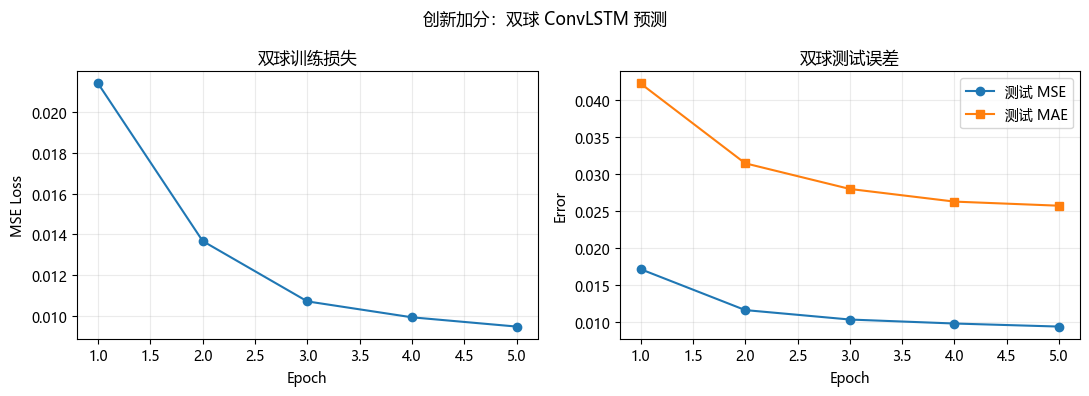

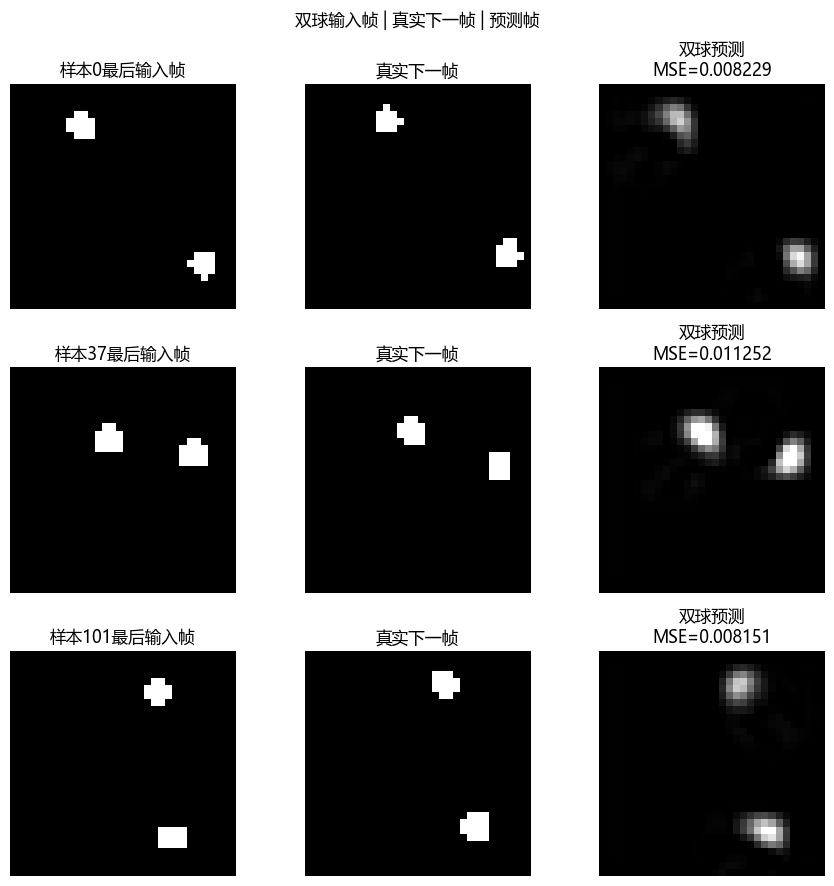

单球基线：MSE=0.004857, MAE=0.014212
双球扩展：MSE=0.009383, MAE=0.025684
MSE相对变化=+93.18%
MAE相对变化=+80.72%


In [5]:
epochs = range(1, 6)
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history['train_loss'], marker='o')
axes[0].set(title='双球训练损失', xlabel='Epoch', ylabel='MSE Loss')
axes[0].grid(alpha=0.25)
axes[1].plot(epochs, history['test_mse'], marker='o', label='测试 MSE')
axes[1].plot(epochs, history['test_mae'], marker='s', label='测试 MAE')
axes[1].set(title='双球测试误差', xlabel='Epoch', ylabel='Error')
axes[1].grid(alpha=0.25)
axes[1].legend()
figure.suptitle('创新加分：双球 ConvLSTM 预测')
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'result_extra_multiball.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(figure)

indices = (0, 37, 101)
sample_inputs = test_x[list(indices)].to(DEVICE)
sample_targets = test_y[list(indices)].to(DEVICE)
model.eval()
with torch.no_grad():
    sample_predictions = model(sample_inputs)
sample_mse = (sample_predictions - sample_targets).pow(2).flatten(1).mean(dim=1)
figure, axes = plt.subplots(3, 3, figsize=(9, 9))
for row_index, sample_index in enumerate(indices):
    images = [sample_inputs[row_index, -1, 0], sample_targets[row_index, 0], sample_predictions[row_index, 0].clamp(0, 1)]
    titles = [f'样本{sample_index}最后输入帧', '真实下一帧', f'双球预测\nMSE={sample_mse[row_index]:.6f}']
    for column_index, (image, title) in enumerate(zip(images, titles)):
        axes[row_index, column_index].imshow(image.cpu(), cmap='gray', vmin=0, vmax=1)
        axes[row_index, column_index].set_title(title)
        axes[row_index, column_index].axis('off')
figure.suptitle('双球输入帧 | 真实下一帧 | 预测帧')
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'result_extra_multiball_pred.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(figure)

with Path('lab02_outputs/results.csv').open(encoding='utf-8-sig') as file:
    single_ball = next(csv.DictReader(file))
single_mse = float(single_ball['test_mse'])
single_mae = float(single_ball['test_mae'])
print(f'单球基线：MSE={single_mse:.6f}, MAE={single_mae:.6f}')
print(f'双球扩展：MSE={test_mse:.6f}, MAE={test_mae:.6f}')
print(f'MSE相对变化={(test_mse / single_mse - 1) * 100:+.2f}%')
print(f'MAE相对变化={(test_mae / single_mae - 1) * 100:+.2f}%')

## 5 报告使用说明

在报告结果分析后增加“创新加分：双球预测”小节，说明只改变数据中的小球数量，模型与训练协议保持基线一致。填写本Notebook打印的双球MSE、MAE和耗时，插入 `lab02_extra_outputs/result_extra_multiball.png` 与 `result_extra_multiball_pred.png`，并讨论目标增加后遮挡、交汇和多运动轨迹带来的难度。